# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [1]:
from pathlib import Path
print(ROOT := Path.cwd())

c:\Users\LENOVO\bootcamp_ruihao_wang\homework\homework7\notebooks


In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# Define folder paths relative to this notebook
ROOT=Path.cwd().parent
raw_dir = ROOT / 'data' / 'raw'
processed_dir = ROOT / 'data' / 'processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at c:\Users\LENOVO\bootcamp_ruihao_wang\homework\homework7\data\raw\outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [3]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [4]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [5]:
def _validate_numeric_series(series: pd.Series) -> None:
    if not isinstance(series, pd.Series):
        raise TypeError('series must be a pandas Series')
    if series.empty:
        raise ValueError('series must contain at least one value')
    if not pd.api.types.is_numeric_dtype(series):
        raise TypeError('series must have a numeric dtype')


def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    _validate_numeric_series(series)
    if k <= 0:
        raise ValueError('k must be positive')

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return ((series < lower) | (series > upper)).fillna(False).astype(bool)


def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    _validate_numeric_series(series)
    if threshold <= 0:
        raise ValueError('threshold must be positive')

    mu = series.mean()
    sigma = series.std(ddof=0)
    if pd.isna(sigma) or sigma == 0:
        return pd.Series(False, index=series.index, dtype=bool)

    z = (series - mu) / sigma
    return z.abs().gt(threshold).fillna(False).astype(bool)

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [6]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    _validate_numeric_series(series)
    if not 0 <= lower < upper <= 1:
        raise ValueError('quantiles must satisfy 0 <= lower < upper <= 1')

    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

## Apply Detection and Create Flags (choose a numeric column)

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
target_col = 'daily_return' if 'daily_return' in numeric_cols else numeric_cols[0]
df['outlier_iqr'] = detect_outliers_iqr(df[target_col], k=1.5)
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)

flag_summary = pd.DataFrame({
    'flagged_count': df[['outlier_iqr', 'outlier_z']].sum().astype(int),
    'flagged_rate': df[['outlier_iqr', 'outlier_z']].mean()
})
flag_summary

Numeric columns in the DataFrame: ['daily_return', 'daily_return_2']


,flagged_count,flagged_rate
outlier_iqr,9,0.078261
outlier_z,5,0.043478


### Visual Checks (boxplot / histogram)

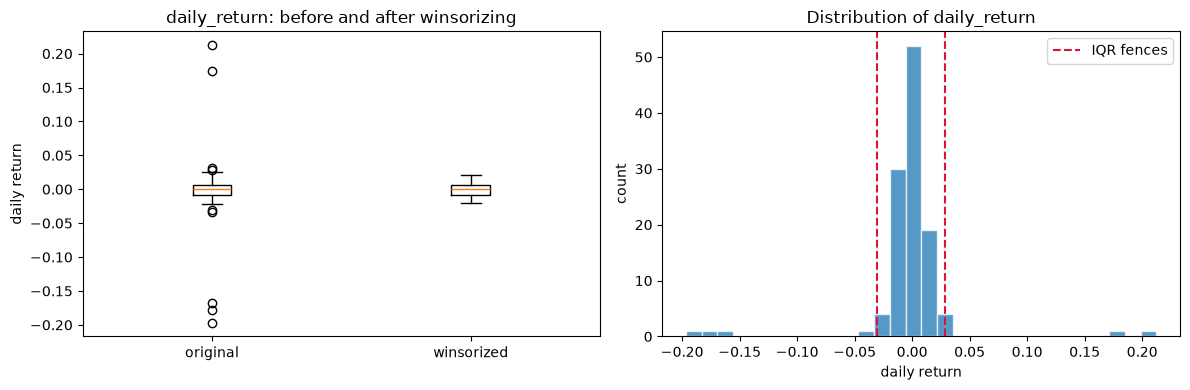

In [8]:
target_clean = df[target_col].dropna()
target_winsorized = winsorize_series(df[target_col], lower=0.05, upper=0.95)
q1, q3 = target_clean.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([target_clean, target_winsorized.dropna()])
axes[0].set_xticks([1, 2], ['original', 'winsorized'])
axes[0].set_title(f'{target_col}: before and after winsorizing')
axes[0].set_ylabel('daily return')

axes[1].hist(target_clean, bins=30, alpha=0.75, edgecolor='white')
axes[1].axvline(lower_fence, color='crimson', linestyle='--', label='IQR fences')
axes[1].axvline(upper_fence, color='crimson', linestyle='--')
axes[1].set_title(f'Distribution of {target_col}')
axes[1].set_xlabel('daily return')
axes[1].set_ylabel('count')
axes[1].legend()
fig.tight_layout()
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [9]:
# Summary-statistics sensitivity analysis: all / remove IQR outliers / winsorize.
series_by_treatment = {
    'all': df[target_col],
    'filtered_iqr': df.loc[~df['outlier_iqr'], target_col],
    'winsorized_5_95': winsorize_series(df[target_col], 0.05, 0.95)
}

summary_comparison = pd.DataFrame({
    name: values.agg(['count', 'mean', 'median', 'std'])
    for name, values in series_by_treatment.items()
}).T
summary_comparison.index.name = 'treatment'
summary_comparison.round(6)

,count,mean,median,std
treatment,,,,
all,115.0,-0.001434,-0.000187,0.040579
filtered_iqr,106.0,-0.000039,-0.000100,0.009443
winsorized_5_95,115.0,-0.000251,-0.000187,0.010623


,n,slope,intercept,r2,mae
treatment,,,,,
all,115.0,0.605869,0.000201,0.961859,0.003951
filtered_iqr,106.0,0.589679,-0.000049,0.573566,0.003851
winsorized_5_95,115.0,0.649705,-0.000017,0.689444,0.003741


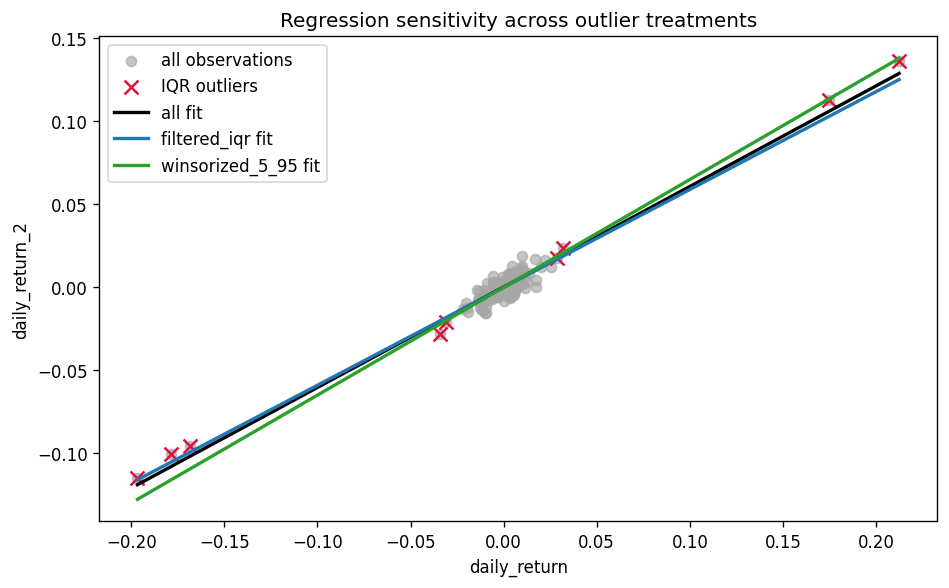

In [10]:
# Regression sensitivity analysis using the two correlated numeric columns.
resp_col = 'daily_return_2' if 'daily_return_2' in df.columns else [
    c for c in numeric_cols if c != target_col
][0]

def fit_and_metrics(data: pd.DataFrame, x_col: str, y_col: str) -> dict:
    """Fit OLS linear regression and return in-sample sensitivity metrics."""
    clean = data[[x_col, y_col]].dropna()
    X = clean[[x_col]].to_numpy()
    y = clean[y_col].to_numpy()
    model = LinearRegression().fit(X, y)
    y_hat = model.predict(X)
    return {
        'n': len(clean),
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': r2_score(y, y_hat),
        'mae': mean_absolute_error(y, y_hat)
    }

df_filtered = df.loc[~df['outlier_iqr']].copy()
df_winsorized = df.copy()
for col in [target_col, resp_col]:
    df_winsorized[col] = winsorize_series(df_winsorized[col], 0.05, 0.95)

regression_results = pd.DataFrame({
    'all': fit_and_metrics(df, target_col, resp_col),
    'filtered_iqr': fit_and_metrics(df_filtered, target_col, resp_col),
    'winsorized_5_95': fit_and_metrics(df_winsorized, target_col, resp_col)
}).T
regression_results.index.name = 'treatment'
display(regression_results.round(6))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[target_col], df[resp_col], color='0.65', alpha=0.65, label='all observations')
ax.scatter(df.loc[df['outlier_iqr'], target_col],
           df.loc[df['outlier_iqr'], resp_col],
           color='crimson', marker='x', s=70, label='IQR outliers')
x_grid = np.linspace(df[target_col].min(), df[target_col].max(), 200)
colors = {'all': 'black', 'filtered_iqr': 'tab:blue', 'winsorized_5_95': 'tab:green'}
for name, row in regression_results.iterrows():
    ax.plot(x_grid, row['slope'] * x_grid + row['intercept'],
            color=colors[name], linewidth=2, label=f'{name} fit')
ax.set_title('Regression sensitivity across outlier treatments')
ax.set_xlabel(target_col)
ax.set_ylabel(resp_col)
ax.legend()
fig.tight_layout()
plt.show()

### Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

**Methods and thresholds.** I used the 1.5×IQR rule as the primary flag because it is robust to the five large shocks and does not require a normal distribution. I also calculated population Z-scores with a 3.0 cutoff as a secondary diagnostic. The Z-score uses `ddof=0` because this exercise describes the complete generated dataset rather than estimating a larger population. For the stretch comparison, I winsorized both regression variables at their 5th and 95th percentiles so every date remained in the analysis. The functions reject empty or nonnumeric inputs and invalid thresholds; missing values are not labeled as outliers.

**Observed impact.** IQR flagged 9 of 115 observations (7.8%), while the 3-sigma rule flagged 5 (4.3%). The difference is expected because extreme values inflate the mean and standard deviation used by Z-scores. Removing IQR outliers changed the `daily_return` mean from -0.001434 to -0.000039 and reduced its standard deviation from 0.040579 to 0.009443; winsorizing produced a mean of -0.000251 and a standard deviation of 0.010623. The median barely changed, which confirms that it is more robust to the shocks.

In the regression, the full-data fit had slope 0.6059, R² 0.9619, and MAE 0.003951. Filtering reduced R² to 0.5736 even though MAE fell slightly to 0.003851; winsorizing gave R² 0.6894 and MAE 0.003741. Therefore, removing outliers did **not** automatically create a better-fitting model. Here the second return series was generated from the first, including the shocks, so the extreme observations contain genuine shared signal and strongly increase the apparent correlation. These are in-sample metrics on different treatments, so they describe sensitivity rather than out-of-sample performance.

**Assumptions and risks.** The IQR approach assumes that quartiles represent normal operating days and that observations beyond the fences deserve review. That may be wrong for heavy-tailed financial returns or changing regimes. The May shocks could be real market events rather than data errors; deleting them would understate tail risk, while winsorizing would preserve the dates but erase part of their magnitude. Conversely, retaining erroneous values could dominate estimates. I would therefore verify flagged dates with domain information, report thresholds explicitly, and present full, filtered, and winsorized results together rather than treating one choice as automatically correct.